# **EDA on Titanic Dataset**

In [39]:
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn as  sns
%matplotlib inline

sns.set(rc={'figure.figsize':(12, 10)})

In [40]:
data = pd.read_csv("titanic_data.csv")

In [41]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
data.shape

(891, 12)

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [44]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## <font color='yellow'>Filling Missing Values </font>

In [45]:
data["Age"].fillna(data["Age"].median(), inplace=True)

In [46]:
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)

In [47]:
data.drop(columns=["Cabin"], inplace=True)

In [48]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## <font color='yellow'>Analysing Survived Column</font>

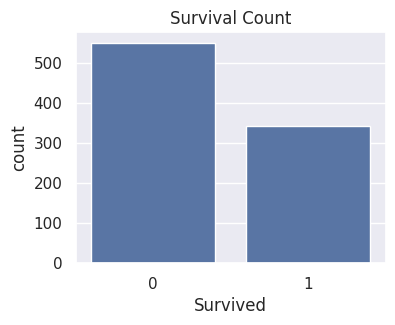

In [50]:
plt.figure(figsize=(4,3))
sns.countplot(x="Survived", data=data)
plt.title("Survival Count")
plt.show()

This indicates that the majority of passengers on the Titanic did not survive the disaster.

## <font color='yellow'>Analysing Sex Column</font>

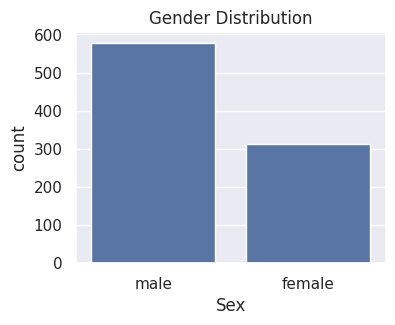

In [51]:
plt.figure(figsize=(4,3))
sns.countplot(x="Sex", data=data)
plt.title("Gender Distribution")
plt.show()

This shows that male passengers were significantly more numerous than female passengers.

## <font color='yellow'>Analysing Pclass Column</font>

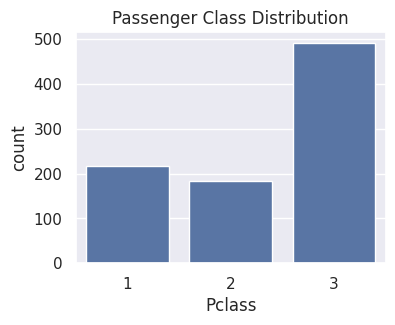

In [52]:
plt.figure(figsize=(4,3))
sns.countplot(x="Pclass", data=data)
plt.title("Passenger Class Distribution")
plt.show()

Most passengers belonged to the third class, compared to the first and second classes.

## <font color='yellow'>Analysing Age Column</font>

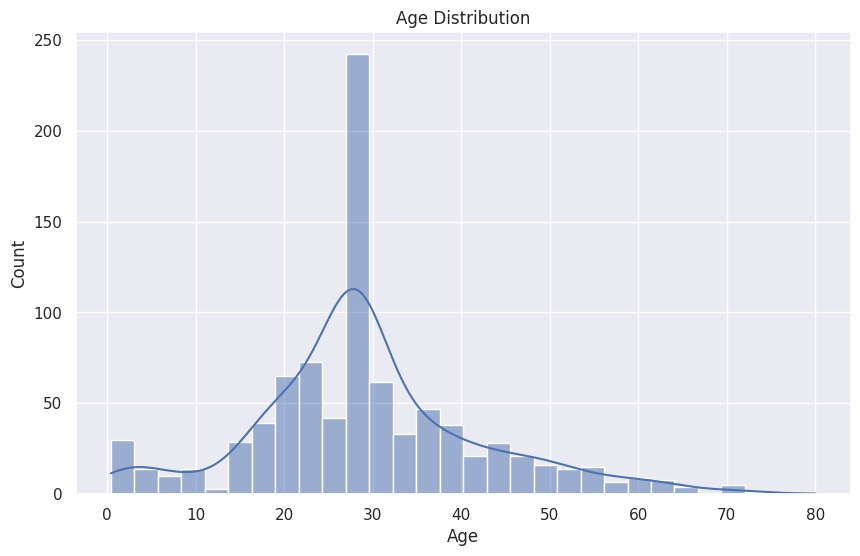

In [54]:
plt.figure(figsize=(10,6))
sns.histplot(data["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

The age distribution reveals that a large proportion of passengers were between 20 and 40 years old, with the distribution being right-skewed.

## <font color='yellow'>Analysing SibSp - Number of siblings / spouses</font>

In [22]:
data['SibSp'].nunique()

7

In [23]:
data['SibSp'].unique()

array([1, 0, 3, 4, 2, 5, 8])

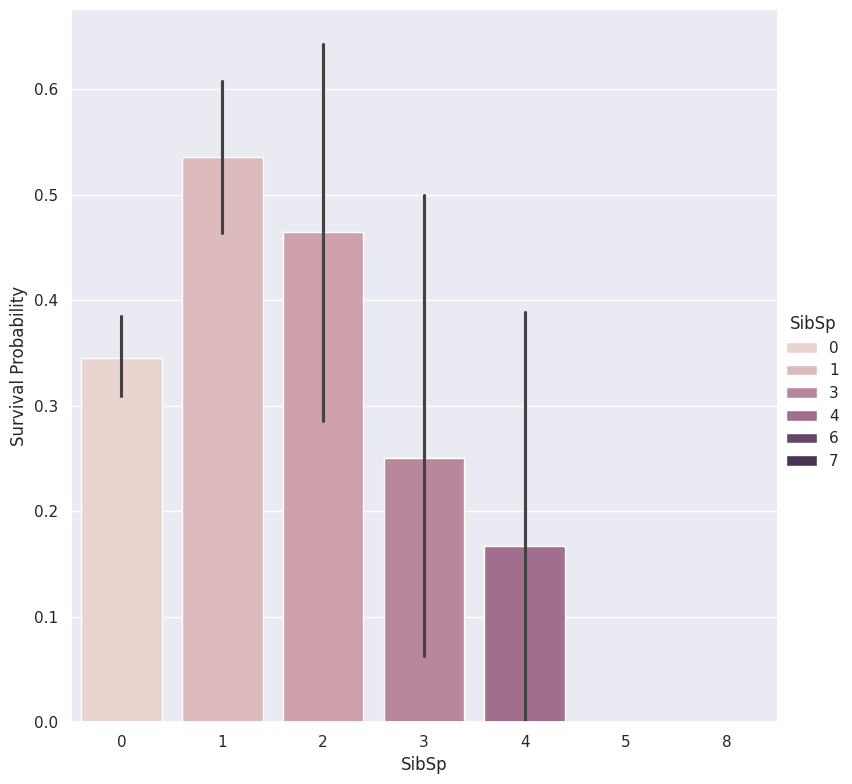

In [24]:
bar_sibsp = sns.catplot(x = 'SibSp', y = 'Survived',hue='SibSp', data = data, kind = "bar", height = 8)
bar_sibsp = bar_sibsp.set_ylabels("Survival Probability")

It seems that passengers having a lot of siblings/spouses have less chance to survive.
Single passengers (0 SibSP) or with two other persons (SibSP 1 or 2) have more chance to survive.

## <font color='yellow'>Analysing Age column</font>

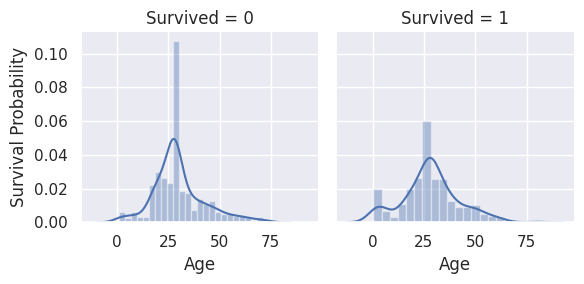

In [25]:
age_g = sns.FacetGrid(data, col = 'Survived')
age_g = age_g.map(sns.distplot, 'Age')
age_g = age_g.set_ylabels("Survival Probability")

I noticed that age distributions are not the same in the survived and not survived subpopulations. Indeed, there is a peak corresponding to young passengers, that have survived. And passengers between 60-80 have less survived.

So, even if "Age" is not correlated with "Survived", we can see that there is age categories of passengers that of have more or less chance to survive.

It seems that very young passengers have more chance to survive.

## <font color='yellow'>Analysing Sex column</font>

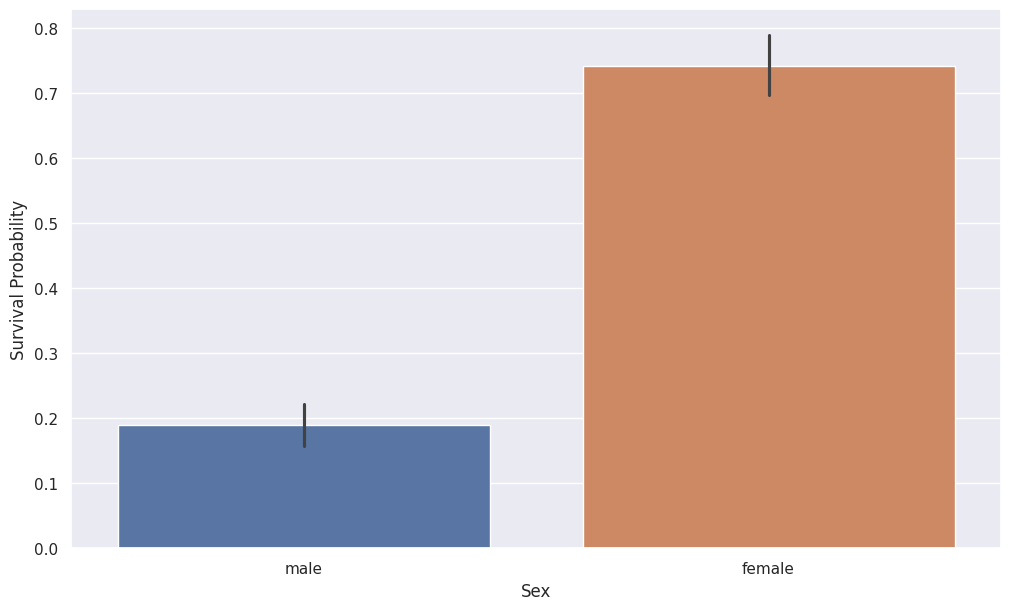

In [29]:
plt.figure(figsize=(12,7))
gender_plot = sns.barplot(x = 'Sex', y = 'Survived', hue = 'Sex', data = data)
gender_plot = gender_plot.set_ylabel("Survival Probability")

In [30]:
data[["Sex", "Survived"]].groupby('Sex').mean()

,Survived
Sex,
female,0.742038
male,0.188908


It is clearly obvious that Male have less chance to survive than Female. So Sex, might play an important role in the prediction of the survival.

## <font color='yellow'>Analysing PClass column</font>

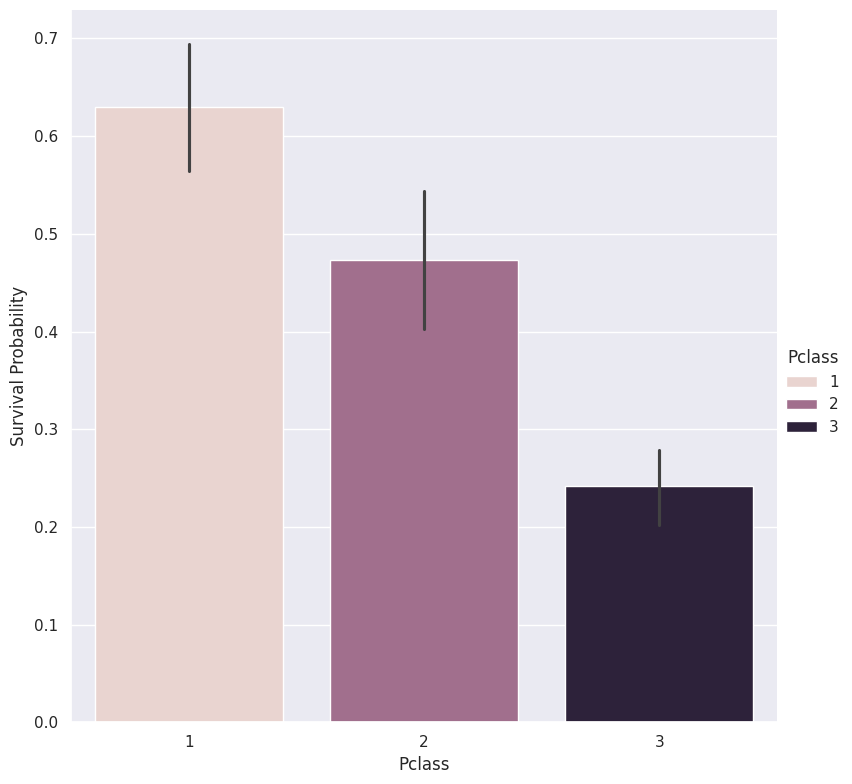

In [31]:
pclass = sns.catplot(x = "Pclass", y = "Survived", hue = "Pclass", data = data, kind = "bar", height = 8)
pclass = pclass.set_ylabels("Survival Probability")

Passengers from higher classes (Pclass 1) survived more

## <font color='yellow'>Analysing Pclass Vs Survived by Sex</font>

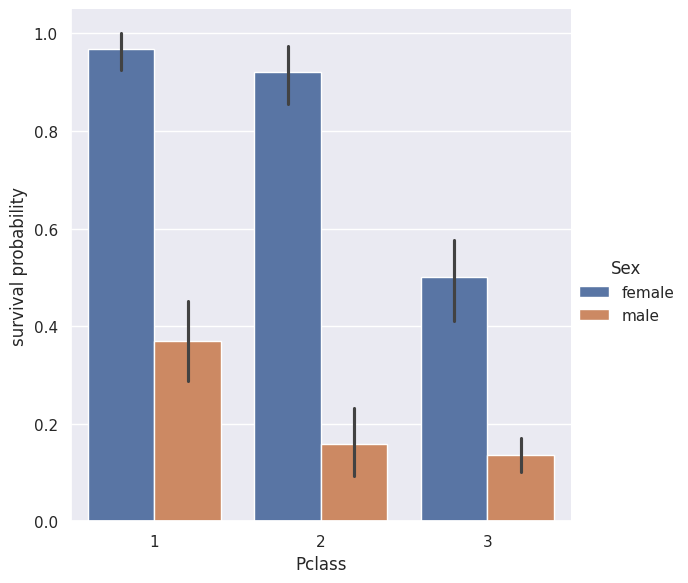

In [32]:
g = sns.catplot(x="Pclass", y="Survived", hue="Sex", data=data, height=6, kind="bar")
g = g.set_ylabels("survival probability")

## <font color='yellow'>Analysing Embarked column</font>

In [33]:
data["Embarked"].value_counts()

,count
Embarked,
S,646
C,168
Q,77


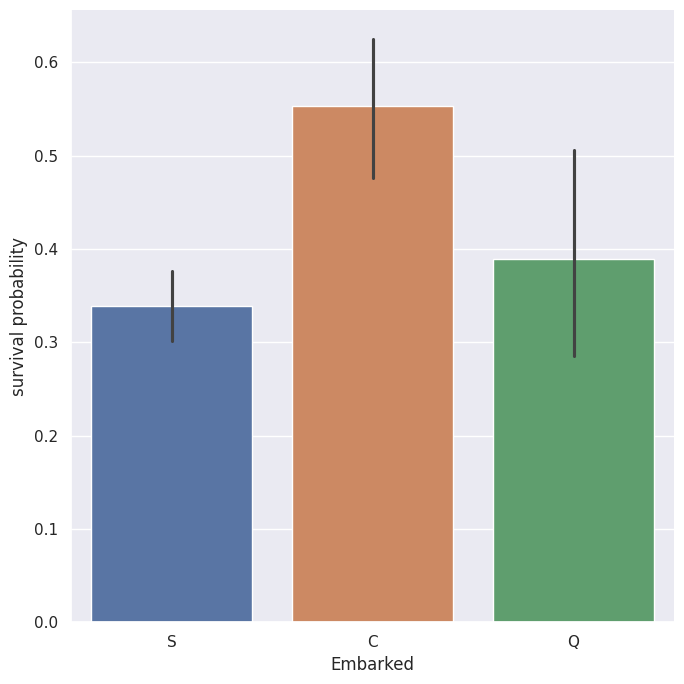

In [34]:
g = sns.catplot(x="Embarked", y="Survived", hue="Embarked", data=data, height=7, kind="bar")
g = g.set_ylabels("survival probability")

Passenger coming from Cherbourg (C) have more chance to survive.

## <font color='yellow'>Pclass vs Embarked </font>

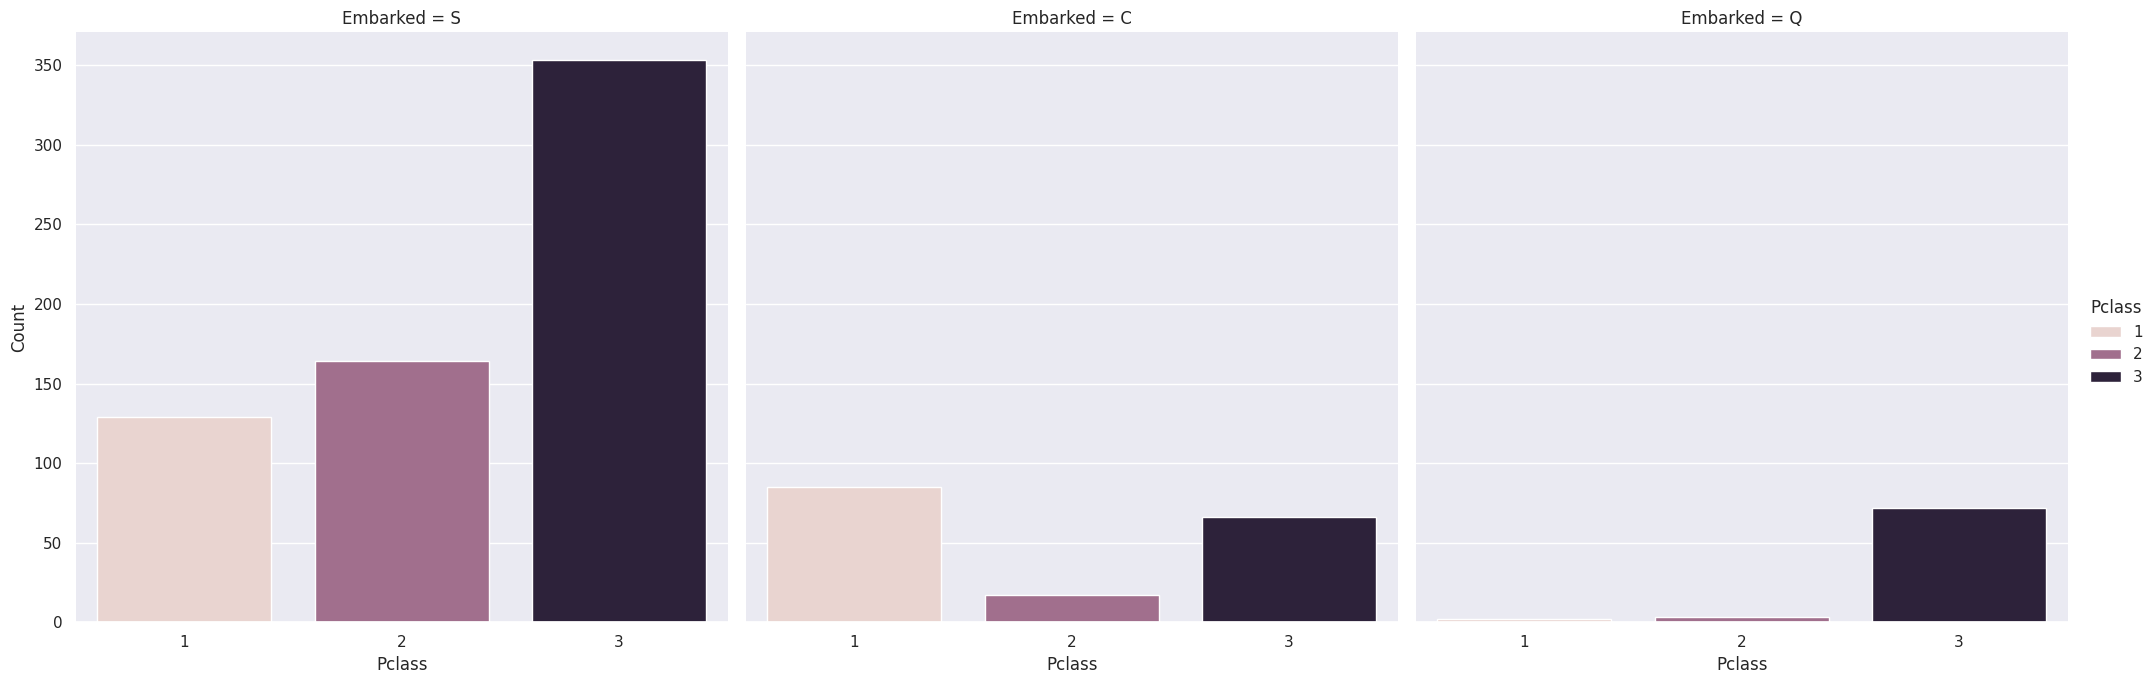

In [35]:
g = sns.catplot(x="Pclass", col="Embarked", hue='Pclass',  data = data , height=7, kind="count")
g.despine(left=True)
g = g.set_ylabels("Count")

## <font color='yellow'>Exploring Sex Vs Embarked</font>

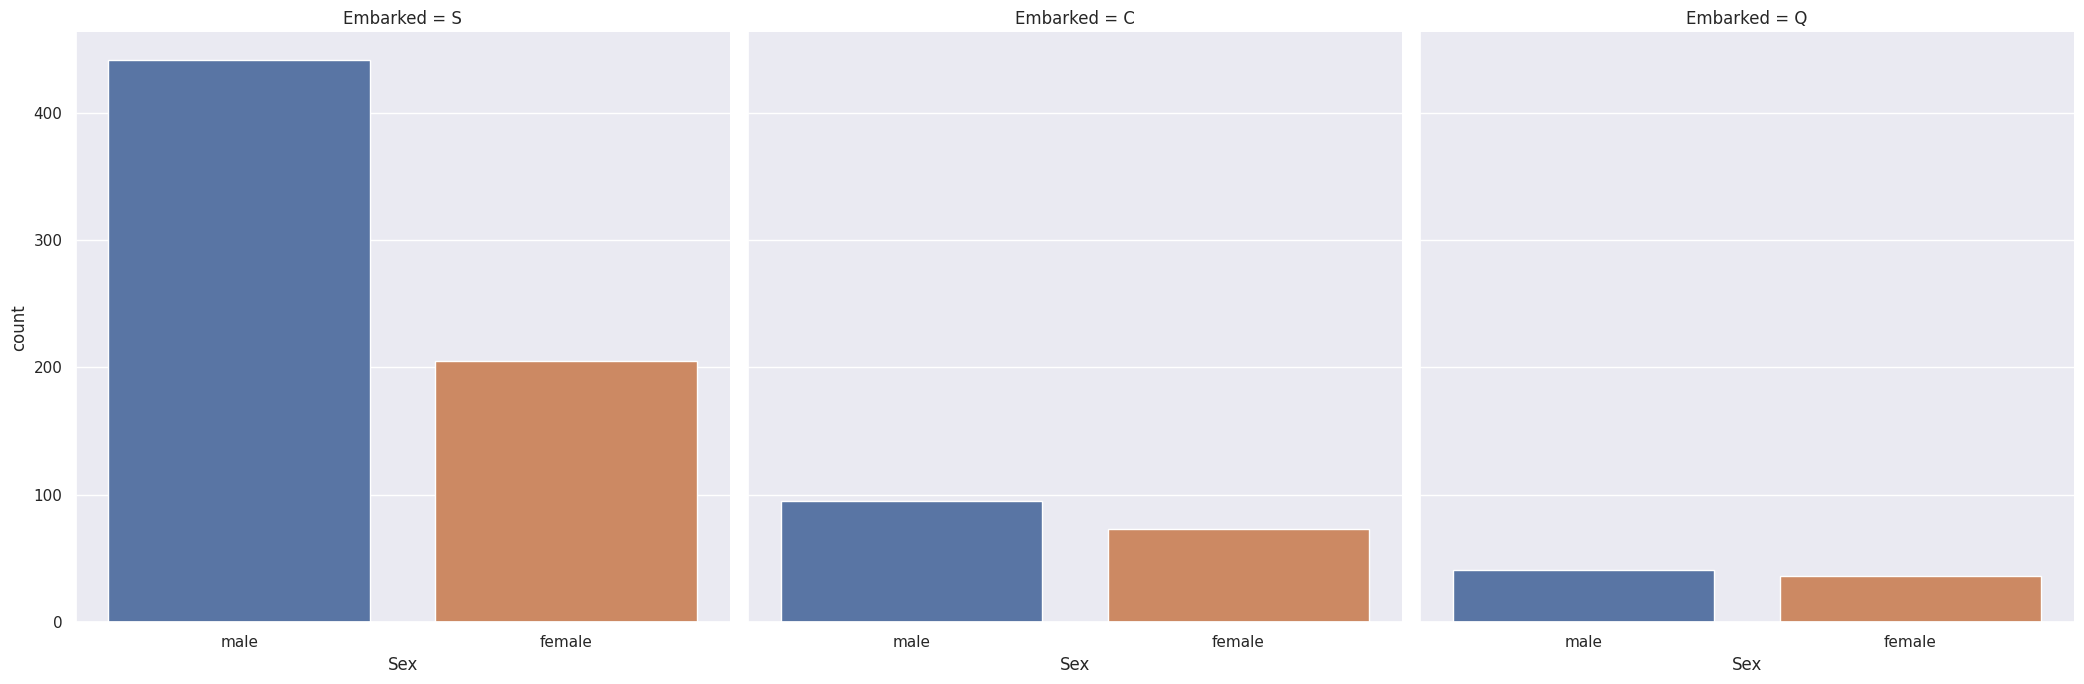

In [36]:
g = sns.catplot(x="Sex", col="Embarked", hue="Sex",  data=data, height=7, kind="count")

Cherbourg passengers are mostly in first class which have the highest survival rate.

Southampton (S) and Queenstown (Q) passangers are mostly in third class.

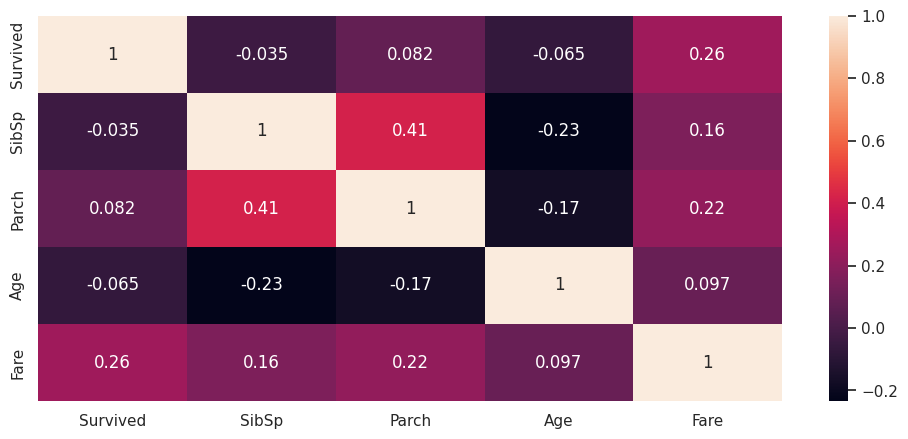

In [55]:
plt.figure(figsize=(12,5))
heatmap = sns.heatmap(data[["Survived", "SibSp","Parch","Age","Fare"]].corr(), annot=True)

### **Conclusion:**
Only Fare Feature seems to have a significance correlation with the Survival Probability.